In [1]:
climate <- matrix(c(
  9.2, 1.1, 0.8, 15,
  6.5, 0.9, 1.2, 30,
  2.3, 0.7, 2.5, 60,
  3.8, 1.0, 1.5, 45,
  7.1, 1.2, 0.9, 25,
  4.2, 1.0, 2.1, 50
), nrow = 6, byrow = TRUE)

colnames(climate) <- c("CO2", "Temp", "Deforestation", "Renewables")
rownames(climate) <- c("A", "B", "C", "D", "E", "F")

print(climate)

  CO2 Temp Deforestation Renewables
A 9.2  1.1           0.8         15
B 6.5  0.9           1.2         30
C 2.3  0.7           2.5         60
D 3.8  1.0           1.5         45
E 7.1  1.2           0.9         25
F 4.2  1.0           2.1         50


In [ ]:
scaled_climate <- scale(climate)
print(scaled_climate)
#question: scaling is important before computing because it ensures all variables are scaled the same

         CO2        Temp Deforestation Renewables
A  1.4544133  0.67734887    -1.0320937 -1.3269776
B  0.3882823 -0.48382062    -0.4423259 -0.4423259
C -1.2701437 -1.64499012     1.4744196  1.3269776
D -0.6778487  0.09676412     0.0000000  0.4423259
E  0.6252003  1.25793362    -0.8846517 -0.7372098
F -0.5199034  0.09676412     0.8846517  0.7372098
attr(,"scaled:center")
          CO2          Temp Deforestation    Renewables 
    5.5166667     0.9833333     1.5000000    37.5000000 
attr(,"scaled:scale")
          CO2          Temp Deforestation    Renewables 
    2.5325218     0.1722401     0.6782330    16.9558250 


In [5]:
cor_matrix <- cor(scaled_climate)
print(round(cor_matrix, 2))

                CO2  Temp Deforestation Renewables
CO2            1.00  0.71         -0.91      -0.99
Temp           0.71  1.00         -0.79      -0.74
Deforestation -0.91 -0.79          1.00       0.97
Renewables    -0.99 -0.74          0.97       1.00


In [8]:
# run only once
lib <- "C:/Users/kobie/R/win-library"
dir.create(lib, recursive = TRUE, showWarnings = FALSE)
.libPaths(lib)
install.packages("reshape2", lib = lib, repos = "https://cloud.r-project.org")
library(reshape2, lib.loc = lib)

melted <- melt(cor_matrix)
head(melted)

also installing the dependencies 'magrittr', 'stringi', 'plyr', 'Rcpp', 'stringr'




package 'magrittr' successfully unpacked and MD5 sums checked
package 'stringi' successfully unpacked and MD5 sums checked
package 'plyr' successfully unpacked and MD5 sums checked
package 'Rcpp' successfully unpacked and MD5 sums checked
package 'stringr' successfully unpacked and MD5 sums checked
package 'reshape2' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\kobie\AppData\Local\Temp\Rtmp0eMvaJ\downloaded_packages


,Var1,Var2,value
,<fct>,<fct>,<dbl>
1,CO2,CO2,1.0000000
2,Temp,CO2,0.7114442
3,Deforestation,CO2,-0.9117162
4,Renewables,CO2,-0.9862370
5,CO2,Temp,0.7114442
6,Temp,Temp,1.0000000


Installing package into 'C:/Users/kobie/R/win-library'
(as 'lib' is unspecified)

also installing the dependencies 'cpp11', 'farver', 'labeling', 'R6', 'RColorBrewer', 'viridisLite', 'gtable', 'isoband', 'S7', 'scales', 'withr'




package 'cpp11' successfully unpacked and MD5 sums checked
package 'farver' successfully unpacked and MD5 sums checked
package 'labeling' successfully unpacked and MD5 sums checked
package 'R6' successfully unpacked and MD5 sums checked
package 'RColorBrewer' successfully unpacked and MD5 sums checked
package 'viridisLite' successfully unpacked and MD5 sums checked
package 'gtable' successfully unpacked and MD5 sums checked
package 'isoband' successfully unpacked and MD5 sums checked
package 'S7' successfully unpacked and MD5 sums checked
package 'scales' successfully unpacked and MD5 sums checked
package 'withr' successfully unpacked and MD5 sums checked
package 'ggplot2' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\kobie\AppData\Local\Temp\Rtmp0eMvaJ\downloaded_packages


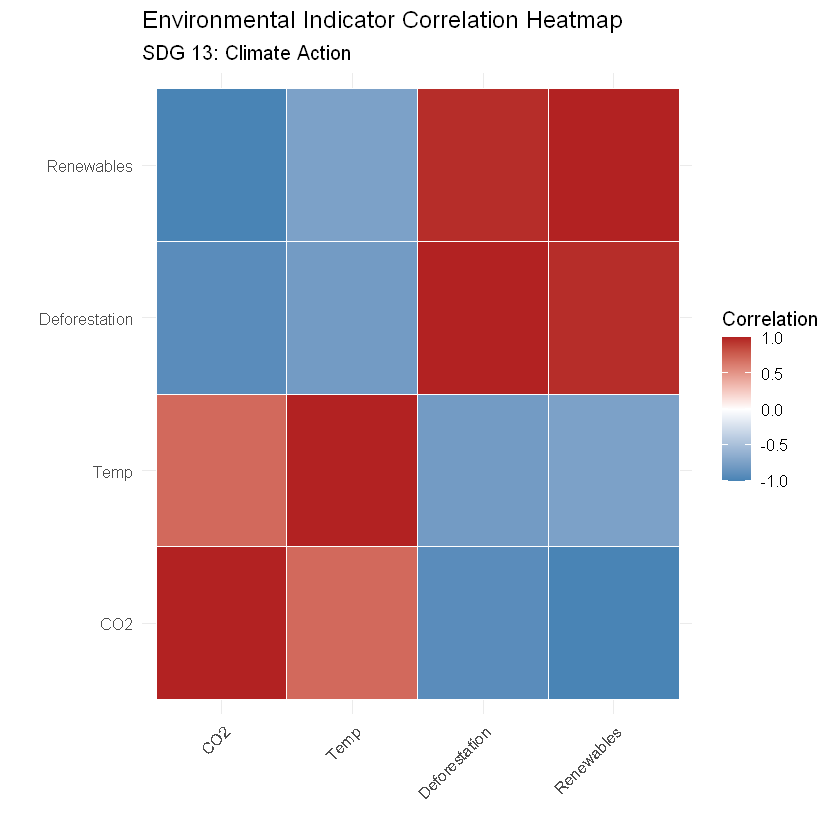

In [9]:
install.packages("ggplot2")  # run only once
library(ggplot2)

ggplot(melted, aes(x = Var1, y = Var2, fill = value)) +
  geom_tile(color = "white", linewidth = 0.5) +
  scale_fill_gradient2(
    low = "steelblue",
    high = "firebrick",
    mid = "white",
    midpoint = 0,
    limit = c(-1, 1),
    name = "Correlation"
  ) +
  theme_minimal(base_size = 12) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  labs(
    title = "Environmental Indicator Correlation Heatmap",
    subtitle = "SDG 13: Climate Action",
    x = "",
    y = ""
  )

In [11]:
climate[3, 4] <- 90  # new renewables value for Country C
scaled_climate <- scale(climate)
cor_matrix <- cor(scaled_climate)
melted <- melt(cor_matrix)

# Re-plot the heatmap (same code as above)
#question:  increasing c's renewable share to 90 made the negative correlations between renewables and other variables stronger.